In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = sns.load_dataset("iris")

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
print("Feature Types:\n")

for col in df.columns:
    if df[col].dtype == "str":
        print(f"{col} → Nominal (Categorical)")
    else:
        print(f"{col} → Numeric")

Feature Types:

sepal_length → Numeric
sepal_width → Numeric
petal_length → Numeric
petal_width → Numeric
species → Nominal (Categorical)


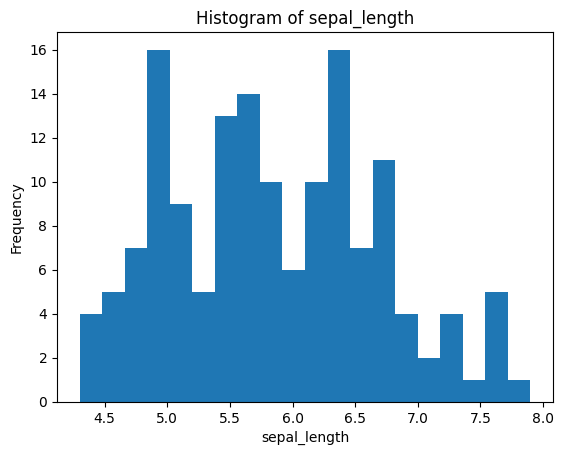


Inference for sepal_length:
Distribution is right-skewed


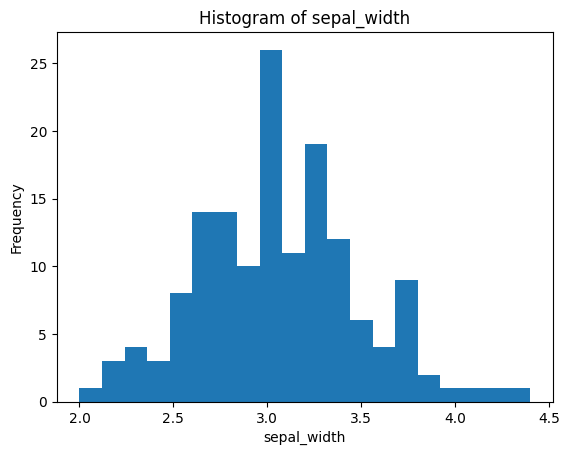


Inference for sepal_width:
Distribution is right-skewed


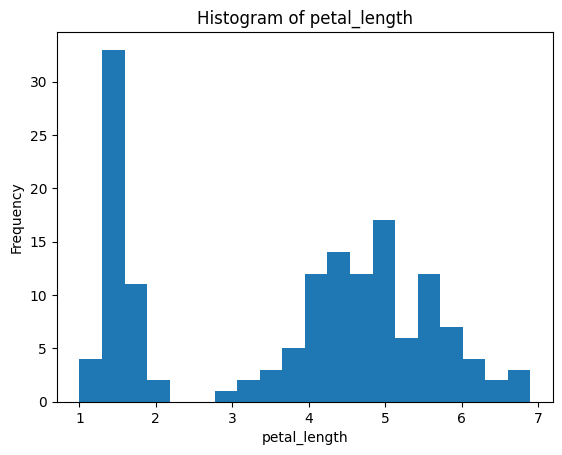


Inference for petal_length:
Distribution is left-skewed


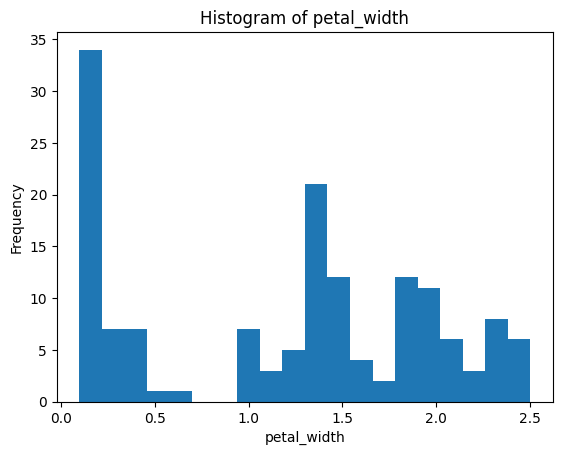


Inference for petal_width:
Distribution is left-skewed


In [7]:
numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    plt.figure()
    plt.hist(df[col], bins=20)
    
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
    plt.show()
    
    print(f"\nInference for {col}:")
    
    if df[col].skew() > 0:
        print("Distribution is right-skewed")
    elif df[col].skew() < 0:
        print("Distribution is left-skewed")
    else:
        print("Distribution is approximately symmetric")

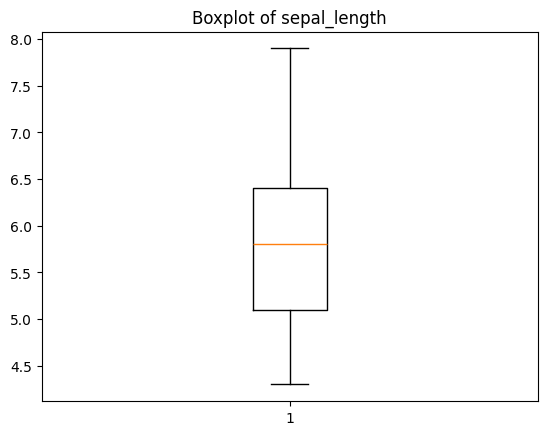

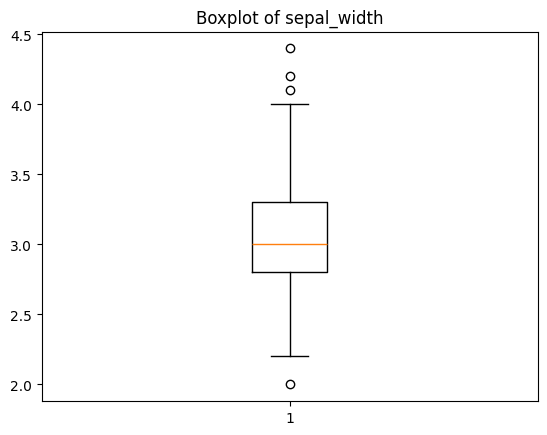

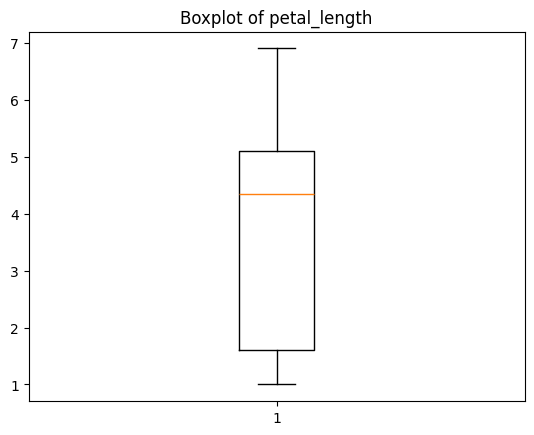

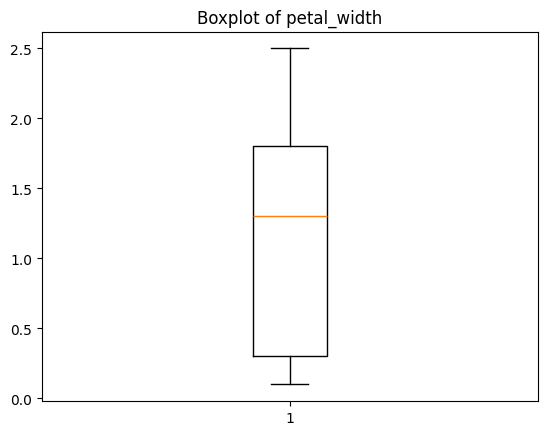

In [9]:
for col in numeric_cols:
    plt.figure()
    plt.boxplot(df[col])
    
    plt.title(f"Boxplot of {col}")
    plt.show()

In [10]:
print("\nOutlier Analysis:\n")

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col}: {len(outliers)} outliers found")


Outlier Analysis:

sepal_length: 0 outliers found
sepal_width: 4 outliers found
petal_length: 0 outliers found
petal_width: 0 outliers found


In [12]:

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

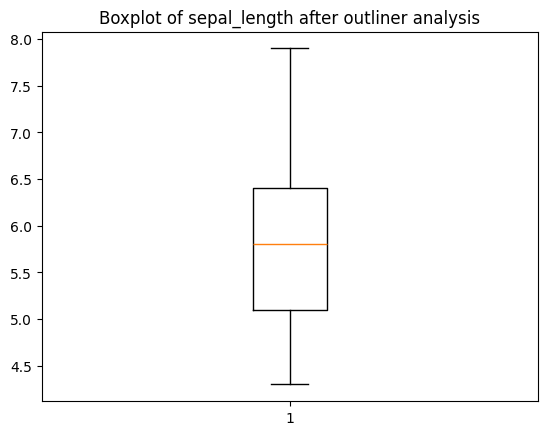

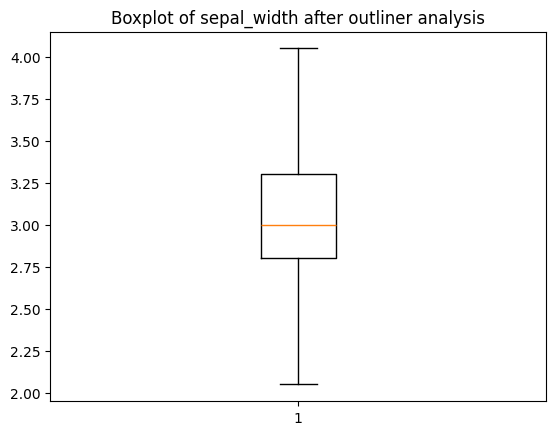

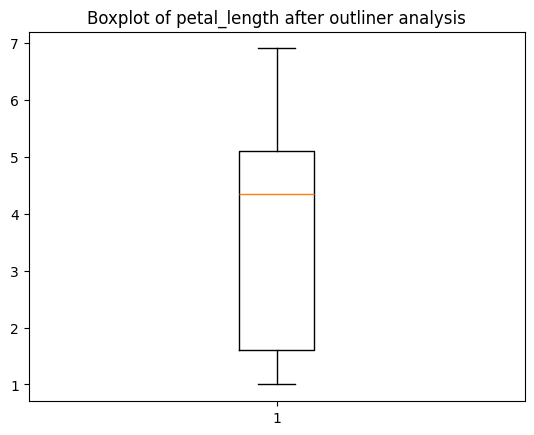

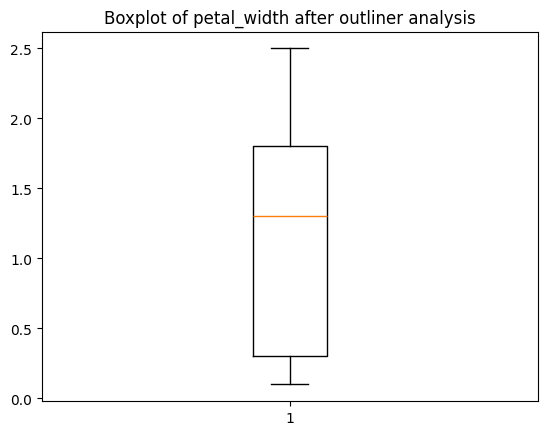

In [13]:
for col in numeric_cols:
    plt.figure()
    plt.boxplot(df[col])
    
    plt.title(f"Boxplot of {col} after outliner analysis")
    plt.show()